# Source-to-Target Reconciliation

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/reconciliation-checker/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/reconciliation-checker/demo.ipynb)

Prove that a table copied from a **source** system into a **target** (warehouse) landed correctly - at one instant, not over time.

## Contents
1. [Setup](#setup)
2. [Build source + target with planted drift](#build)
3. [Reconcile](#reconcile)
4. [Read the findings: missing / extra / mismatches](#findings)
5. [Chart: match rate + mismatches per column](#chart)
6. [Summary](#summary)
7. [Try your own data](#tryyourown)

This notebook is **self-contained** - the reconciliation logic is duplicated here so it runs anywhere with no local imports.

<a id="setup"></a>
## 1. Setup

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Seeded so this notebook reproduces the exact same drift every run.
SEED = 42
DEFAULT_TOLERANCE = 1e-6

<a id="build"></a>
## 2. Build source + target with planted drift

The source is the system of record. The target is an imperfect copy - we corrupt it the way a real bad load does: some rows never land, a stray row sneaks in, and a couple of cell values silently drift.

In [2]:
def make_sample_data(seed: int = SEED) -> Dict[str, pd.DataFrame]:
    """A source orders table and its imperfect target copy, with planted drift:
      - 3 rows MISSING in target (dropped in transit)
      - 1 EXTRA row in target (a stray insert)
      - 2 cell value mismatches on shared keys (a re-rounded amount, a flipped status)
      - the amount sum lands OUTSIDE tolerance because of the missing rows
    """
    rng = np.random.default_rng(seed)
    n = 50
    order_id = np.arange(1000, 1000 + n)
    amount = rng.normal(120, 30, n).round(2)
    status = rng.choice(["paid", "pending", "refunded"], n, p=[0.7, 0.2, 0.1])
    region = rng.choice(["North", "South", "East", "West"], n)

    source = pd.DataFrame({
        "order_id": order_id, "amount": amount,
        "status": status, "region": region,
    })

    target = source.copy()
    # 3 rows never made it into the warehouse.
    target = target[~target["order_id"].isin([1005, 1020, 1044])].reset_index(drop=True)
    # 1 stray row that should not exist in the target.
    stray = pd.DataFrame([{"order_id": 9999, "amount": 88.0, "status": "paid", "region": "North"}])
    target = pd.concat([target, stray], ignore_index=True)
    # 2 silent cell drifts on rows that DID land.
    target.loc[target["order_id"] == 1002, "amount"] = (
        float(source.loc[source["order_id"] == 1002, "amount"].iloc[0]) + 5.0)
    target.loc[target["order_id"] == 1010, "status"] = "pending"
    return {"source": source, "target": target}

data = make_sample_data()
source, target = data["source"], data["target"]
print(f"source rows: {len(source)}   target rows: {len(target)}")
source.head()

source rows: 50   target rows: 48


,order_id,amount,status,region
0,1000,129.14,pending,South
1,1001,88.80,paid,South
2,1002,142.51,pending,West
3,1003,148.22,pending,West
4,1004,61.47,paid,South


<a id="reconcile"></a>
## 3. Reconcile

The reconciler compares on a chosen key column and produces an explainable verdict across every dimension.

In [3]:
@dataclass
class CellMismatch:
    key: object
    column: str
    source_value: object
    target_value: object
    reason: str

@dataclass
class AggCheck:
    column: str
    agg: str
    source_value: float
    target_value: float
    delta: float
    tolerance: float
    passed: bool
    reason: str

@dataclass
class ReconResult:
    ok: bool
    error: Optional[str] = None
    key: str = ""
    source_rows: int = 0
    target_rows: int = 0
    row_delta: int = 0
    shared_keys: int = 0
    missing_keys: List[object] = field(default_factory=list)
    extra_keys: List[object] = field(default_factory=list)
    compared_columns: List[str] = field(default_factory=list)
    cell_mismatches: List[CellMismatch] = field(default_factory=list)
    agg_checks: List[AggCheck] = field(default_factory=list)
    match_rate: float = 0.0
    passed: bool = False


def _values_match(a: object, b: object, tolerance: float) -> bool:
    """Two NaNs agree; numbers compare within tolerance; else trimmed strings."""
    a_null = a is None or (isinstance(a, float) and np.isnan(a)) or pd.isna(a)
    b_null = b is None or (isinstance(b, float) and np.isnan(b)) or pd.isna(b)
    if a_null and b_null:
        return True
    if a_null or b_null:
        return False
    a_num = isinstance(a, (int, float, np.integer, np.floating))
    b_num = isinstance(b, (int, float, np.integer, np.floating))
    if a_num and b_num:
        return abs(float(a) - float(b)) <= tolerance
    return str(a).strip() == str(b).strip()


def reconcile(source_df, target_df, key, tolerance=DEFAULT_TOLERANCE, agg_columns=None):
    """Row-count delta, missing/extra keys, cell mismatches, and aggregate checks."""
    if source_df is None or target_df is None:
        return ReconResult(ok=False, error="both frames required", key=key)
    if key not in source_df.columns:
        return ReconResult(ok=False, error=f"key '{key}' not in source", key=key)
    if key not in target_df.columns:
        return ReconResult(ok=False, error=f"key '{key}' not in target", key=key)

    r = ReconResult(ok=True, key=key)
    r.source_rows, r.target_rows = len(source_df), len(target_df)
    r.row_delta = r.target_rows - r.source_rows
    if source_df.empty and target_df.empty:
        r.match_rate, r.passed = 1.0, True
        return r

    src = source_df.drop_duplicates(subset=[key]).set_index(key)
    tgt = target_df.drop_duplicates(subset=[key]).set_index(key)
    src_keys, tgt_keys = set(src.index), set(tgt.index)
    r.missing_keys = sorted([k for k in (src_keys - tgt_keys)], key=str)
    r.extra_keys = sorted([k for k in (tgt_keys - src_keys)], key=str)
    shared = sorted(src_keys & tgt_keys, key=str)
    r.shared_keys = len(shared)

    common_cols = [c for c in source_df.columns if c in target_df.columns and c != key]
    r.compared_columns = common_cols
    src_s = src.loc[shared] if shared else src.iloc[0:0]
    tgt_s = tgt.loc[shared] if shared else tgt.iloc[0:0]

    bad_keys = set()
    for k in shared:
        for col in common_cols:
            sv, tv = src_s.at[k, col], tgt_s.at[k, col]
            if not _values_match(sv, tv, tolerance):
                bad_keys.add(k)
                r.cell_mismatches.append(CellMismatch(
                    k, col, sv, tv,
                    f"key {k!r}, column '{col}': source={sv!r} vs target={tv!r}"))

    if agg_columns is None:
        agg_columns = [c for c in common_cols
                       if pd.api.types.is_numeric_dtype(source_df[c])
                       and pd.api.types.is_numeric_dtype(target_df[c])]
    for col in agg_columns:
        s_sum = float(pd.to_numeric(source_df[col], errors="coerce").sum())
        t_sum = float(pd.to_numeric(target_df[col], errors="coerce").sum())
        delta = t_sum - s_sum
        agg_tol = max(tolerance, tolerance * max(r.source_rows, 1))
        passed = abs(delta) <= agg_tol
        r.agg_checks.append(AggCheck(col, "sum", s_sum, t_sum, delta, agg_tol, passed,
            f"sum('{col}'): source={s_sum:g} vs target={t_sum:g}, delta={delta:g}"))

    clean = len(shared) - len(bad_keys)
    r.match_rate = round(clean / (r.source_rows or 1), 4)
    r.passed = (not r.missing_keys and not r.extra_keys
                and not r.cell_mismatches and all(a.passed for a in r.agg_checks))
    return r

result = reconcile(source, target, key="order_id")
print("verdict:", "PASS" if result.passed else "FAIL")
print("match rate:", f"{result.match_rate:.2%}")

verdict: FAIL
match rate: 90.00%


<a id="findings"></a>
## 4. Read the findings

Each dimension is independently explainable - a steward can defend the verdict line by line.

In [4]:
summary = pd.DataFrame([
    ("source_rows", result.source_rows),
    ("target_rows", result.target_rows),
    ("row_delta", result.row_delta),
    ("shared_keys", result.shared_keys),
    ("missing_in_target", len(result.missing_keys)),
    ("extra_in_target", len(result.extra_keys)),
    ("cell_mismatches", len(result.cell_mismatches)),
    ("match_rate", f"{result.match_rate:.2%}"),
    ("verdict", "PASS" if result.passed else "FAIL"),
], columns=["metric", "value"])
summary

,metric,value
0,source_rows,50
1,target_rows,48
2,row_delta,-2
3,shared_keys,47
4,missing_in_target,3
5,extra_in_target,1
6,cell_mismatches,2
7,match_rate,90.00%
8,verdict,FAIL


In [5]:
print("Keys MISSING in target (did not land):", result.missing_keys)
print("Keys EXTRA in target (should not exist):", result.extra_keys)

mm = pd.DataFrame([{
    "key": m.key, "column": m.column,
    "source_value": m.source_value, "target_value": m.target_value,
} for m in result.cell_mismatches])
print("\nCell-level value mismatches:")
mm

Keys MISSING in target (did not land): [1005, 1020, 1044]
Keys EXTRA in target (should not exist): [9999]

Cell-level value mismatches:


,key,column,source_value,target_value
0,1002,amount,142.51,147.51
1,1010,status,paid,pending


In [6]:
print("Aggregate checks (scale-level cross-check):")
for a in result.agg_checks:
    print(f"  [{'PASS' if a.passed else 'FAIL'}] {a.reason} (tolerance {a.tolerance:g})")

Aggregate checks (scale-level cross-check):
  [FAIL] sum('amount'): source=6136.8 vs target=5910.92, delta=-225.88 (tolerance 5e-05)


<a id="chart"></a>
## 5. Chart: match rate + mismatches per column

One figure a reviewer can scan: how close the copy came, and where the value drift concentrated.

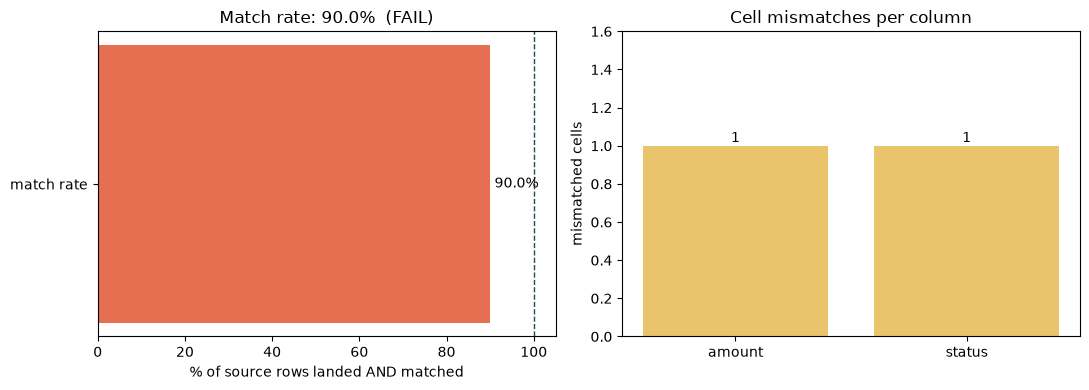

Saved reconciliation_report.png (dpi=150)


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: match-rate bar against the 100% target line.
rate = result.match_rate * 100
ax1.barh(["match rate"], [rate], color="#2a9d8f" if result.passed else "#e76f51")
ax1.axvline(100, color="#264653", linestyle="--", linewidth=1)
ax1.set_xlim(0, 105)
ax1.set_xlabel("% of source rows landed AND matched")
ax1.set_title(f"Match rate: {rate:.1f}%  ({'PASS' if result.passed else 'FAIL'})")
ax1.text(rate + 1, 0, f"{rate:.1f}%", va="center")

# Right: cell mismatches counted per column - shows WHERE drift landed.
from collections import Counter
counts = Counter(m.column for m in result.cell_mismatches)
if counts:
    cols, vals = list(counts.keys()), list(counts.values())
    ax2.bar(cols, vals, color="#e9c46a")
    ax2.set_ylabel("mismatched cells")
    ax2.set_title("Cell mismatches per column")
    for i, v in enumerate(vals):
        ax2.text(i, v + 0.02, str(v), ha="center")
else:
    ax2.text(0.5, 0.5, "no cell mismatches", ha="center", va="center")
    ax2.set_title("Cell mismatches per column")
ax2.set_ylim(0, max([1] + list(counts.values())) + 0.6)

plt.tight_layout()
plt.savefig("reconciliation_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved reconciliation_report.png (dpi=150)")

<a id="summary"></a>
## 6. Summary

The built-in sample plants every finding type, and the checker recovers all of them:

- **Row delta of -2** - the target has 2 fewer rows than the source.
- **3 keys missing in target** (1005, 1020, 1044) - rows that never landed.
- **1 extra key in target** (9999) - a stray row.
- **2 cell mismatches** - order 1002's amount drifted +5.00, order 1010's status flipped paid -&gt; pending.
- **Aggregate sum check FAILS** - the amount total is off because rows went missing.
- **Verdict: FAIL at a 90% match rate** - a copy passes only when every dimension agrees.

This is cross-system correctness at one instant. A clean reconciliation is *evidence*, not proof, and the tolerances are a judgment call - so treat the verdict as a decision aid, not a certificate.

<a id="tryyourown"></a>
## 7. Try your own data

Uncomment and point at your own source / target CSVs.

In [8]:
# source = pd.read_csv("my_source.csv")
# target = pd.read_csv("my_target.csv")
# result = reconcile(source, target, key="your_key_column", tolerance=0.01)
# print("PASS" if result.passed else "FAIL", f"({result.match_rate:.2%})")
# pd.DataFrame([{"key": m.key, "column": m.column,
#                "source": m.source_value, "target": m.target_value}
#               for m in result.cell_mismatches])

---
Built by Phoebe Fu - [github.com/phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - Day 99